# Etapa I — Integración y Obtención de Datos Maestros
**Proyecto:** Inteligencia Deportiva — Cruz Azul F.C.  
**Materia:** Calidad y Preprocesamiento de Datos  
**Framework:** DAMA-DMBOK  

Esta notebook cubre la **primera etapa del pipeline**:
1. Estandarización de las 4 fuentes heterogéneas a formato tabular
2. Definición del **modelo canónico** de jugador y partido
3. **Record linkage** para reconciliar nombres de jugadores entre fuentes
4. **Deduplicación** de registros (doble nacionalidad, renombres de equipo)
5. **Fusión** en datasets maestros exportados a Parquet

---
### Fuentes de datos (`datos_final/`)
| # | Archivo | Formato | Contenido |
|---|---|---|---|
| 1 | `partidos_historicos_ligamx.csv` | CSV | 4 080 partidos Liga MX 2010–2024 |
| 2 | `perfiles_jugadores_historico.json` | JSON anidado | 1 150 jugadores con datos de 3 sub-fuentes |
| 3 | `scouting_historico_ligamx.txt` | TXT ancho fijo | Reporte de scouting con métricas por temporada |
| 4 | `valor_mercado_historico.xlsx` | XLSX | Valores de mercado e inconsistencias etiquetadas |

### Problemáticas que esta etapa atiende
| Prob. | Descripción | Dimensión DAMA |
|---|---|---|
| #1 | Nombres distintos del mismo jugador entre fuentes | Consistencia |
| #3 | Jugadores con doble nacionalidad registrados dos veces | Unicidad |
| #4 | Equipos renombrados entre temporadas | Integridad referencial |

In [19]:
import os
import io
import json
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from rapidfuzz import fuzz

# Rutas 
BASE   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA   = os.path.join(BASE, 'datos_final')
MASTER = os.path.join(BASE, 'datos_master')
os.makedirs(MASTER, exist_ok=True)

# Paleta Cruz Azul
AZUL, ROJO, GRIS = '#003DA5', '#C8102E', '#888888'
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

print('BASE   :', BASE)
print('DATA   :', DATA)
print('MASTER :', MASTER)

BASE   : /Users/milenafer/Desktop/claude/Calidad_PFinal
DATA   : /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_final
MASTER : /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master


---
## 1. Carga y Estandarización de Fuentes

Cada fuente viene en un formato diferente. Los convertimos a DataFrames tabulares con columnas homogéneas antes de cualquier procesamiento posterior.

In [20]:
# Fuente 1: Partidos históricos (CSV) 
df_partidos = pd.read_csv(os.path.join(DATA, 'partidos_historicos_ligamx.csv'))
df_partidos['date'] = pd.to_datetime(df_partidos['date'], errors='coerce')

print(f'Fuente 1 — Partidos CSV : {df_partidos.shape[0]:,} filas × {df_partidos.shape[1]} columnas')
display(df_partidos.head(3))

Fuente 1 — Partidos CSV : 4,080 filas × 17 columnas


,match_id,season,season_year,half,round,date,home_team_id,home_team,away_team_id,away_team,home_goals,away_goals,home_goals_ht,away_goals_ht,venue,result_home,involves_cruz_azul
0,1000,Apertura 2010,2010,apertura,1,2010-07-01,T012,Club Tijuana,T008,Atlas Guadalajara,1,1,1,1,Estadio Caliente,D,0
1,1001,Apertura 2010,2010,apertura,1,2010-07-01,T007,Pumas UNAM,T017,Puebla FC,2,1,1,1,Estadio Olímpico Universitario,W,0
2,1002,Apertura 2010,2010,apertura,1,2010-07-01,T002,América,T015,Impulsora Necaxa,3,1,3,0,Estadio Azteca,W,0


In [21]:
# Fuente 2: Perfiles de jugadores (JSON anidado)
with open(os.path.join(DATA, 'perfiles_jugadores_historico.json'), encoding='utf-8') as f:
    raw_json = json.load(f)

print('Metadata del dataset:')
for k, v in raw_json['metadata'].items():
    if not isinstance(v, (dict, list)):
        print(f'  {k}: {v}')

# Aplanar la estructura anidada: jugadores[*] -> fila del DataFrame
rows = []
for j in raw_json['jugadores']:
    consolidado = j['datos_consolidados']
    rendimiento = consolidado.pop('rendimiento', {})
    row = {
        'player_id'          : j['player_id'],
        # Nombres por fuente (inconsistencia #1)
        'nombre_football_csv': j['fuentes']['football_csv']['nombre'],
        'nombre_transfermarkt': j['fuentes']['transfermarkt']['nombre'],
        'nombre_fifa'        : j['fuentes']['fifa']['nombre'],
        # Atributos FIFA
        'fifa_overall'       : j['fuentes']['fifa'].get('overall'),
        'fifa_pace'          : j['fuentes']['fifa'].get('pace'),
        'fifa_shooting'      : j['fuentes']['fifa'].get('shooting'),
        'fifa_passing'       : j['fuentes']['fifa'].get('passing'),
        'fifa_dribbling'     : j['fuentes']['fifa'].get('dribbling'),
        'fifa_defending'     : j['fuentes']['fifa'].get('defending'),
        'fifa_physical'      : j['fuentes']['fifa'].get('physical'),
        # Valores Transfermarkt
        'valor_mercado_eur'  : j['fuentes']['transfermarkt'].get('valor_mercado_eur'),
        'transfer_paid_eur'  : j['fuentes']['transfermarkt'].get('transfer_paid_eur'),
        'tm_nota'            : j['fuentes']['transfermarkt'].get('nota', ''),
        # Datos consolidados
        **consolidado,
        # Rendimiento
        **rendimiento,
        # Inconsistencias etiquetadas
        'inconsistencias': '|'.join(inc.get('tipo', str(inc)) if isinstance(inc, dict) else str(inc)for inc in j.get('inconsistencias_detectadas', []))
    }
    rows.append(row)

df_jugadores = pd.DataFrame(rows)
print(f'\nFuente 2 — Jugadores JSON: {df_jugadores.shape[0]:,} filas × {df_jugadores.shape[1]} columnas')
display(df_jugadores.head(3))

Metadata del dataset:
  dataset: Liga MX — Perfiles de jugadores 2010-2024
  total_registros: 1150
  rango_temporal: 2010-2024

Fuente 2 — Jugadores JSON: 1,150 filas × 35 columnas


,player_id,nombre_football_csv,nombre_transfermarkt,nombre_fifa,fifa_overall,fifa_pace,fifa_shooting,fifa_passing,fifa_dribbling,fifa_defending,...,minutos_jugados,partidos,partidos_casa,goles_casa,partidos_fuera,goles_fuera,tarjetas_amarillas,tarjetas_rojas,g_a_por_90,inconsistencias
0,P0001,García J.,Jonathan García,J. García,65,84,35,82,52,31,...,846,9,4,0,5,1,0,0,0.319,
1,P0002,Ríos M.,Michael Ríos,M. Ríos,65,74,35,73,73,42,...,510,5,2,0,3,1,5,1,0.176,
2,P0003,Medina E.,Ezequiel Medina,E. Medina,63,64,32,75,75,63,...,829,9,4,0,5,0,4,2,0.217,


In [22]:
# Fuente 3: Scouting (TXT ancho fijo) 
# El archivo tiene 6 lineas de cabecera, luego encabezado de columnas,
# separador y datos. Se parsea con read_fwf.
lines_raw = open(os.path.join(DATA, 'scouting_historico_ligamx.txt'),
                 encoding='utf-8').readlines()

header_line = lines_raw[7]   # línea con nombres de columnas
data_lines  = [l for l in lines_raw[9:]
               if l.strip() and l.strip()[0] == 'P' and l.strip()[1:5].isdigit()]

df_scouting = pd.read_fwf(
    io.StringIO(header_line + ''.join(data_lines)),
    header=0
)
# Renombrar columnas al esquema interno
col_map = {
    'ID'     : 'player_id',
    'NOMBRE_TM'  : 'sc_nombre_tm',
    'NOMBRE_FIFA': 'sc_nombre_fifa',
    'NOMBRE_CSV' : 'sc_nombre_csv',
    'POS'    : 'sc_posicion',
    'NAC          EXT': 'sc_nac_ext',   # columna fusionada por fwf
    'EDAD'   : 'sc_edad',
    'TEMP           EQUIPO': 'sc_temp_equipo',
    'OVR'    : 'sc_overall',
    'MVAL_EUR'   : 'sc_mval_eur',
    'TPAG_EUR'   : 'sc_tpag_eur',
    'GOLES'  : 'sc_goles',
    'ASIS'   : 'sc_asistencias',
    'MINS'   : 'sc_minutos',
    'G+A/90' : 'sc_ga_90',
}
df_scouting.rename(columns={k: v for k, v in col_map.items()
                             if k in df_scouting.columns}, inplace=True)
# Limpiar columnas residuales del parseo de ancho fijo
df_scouting.drop(columns=[c for c in df_scouting.columns
                           if c.startswith('Unnamed')], inplace=True)
# Limpiar valores numéricos con comas (ej. '750,000' -> 750000)
for col in ['sc_mval_eur', 'sc_tpag_eur']:
    if col in df_scouting.columns:
        df_scouting[col] = (df_scouting[col].astype(str)
                            .str.replace(',', '', regex=False)
                            .pipe(pd.to_numeric, errors='coerce'))

print(f'Fuente 3 — Scouting TXT: {df_scouting.shape[0]:,} filas × {df_scouting.shape[1]} columnas')
display(df_scouting.head(3))

Fuente 3 — Scouting TXT: 1,143 filas × 16 columnas


,P0006,Diego Suárez,D.,Suárez,Suárez D.,CM,España SÍ,24,Apertura 2013 Monarcas Morelia,62,"1,300,000","1,791,004",1,0,530,0.17
0,P0008,Ignacio López,I.,López,López I.,CM,Senegal SÍ,29,Apertura 2024 Club León,74,"2,050,000","3,045,294",2,3,2003,0.225
1,P0009,Fernando Reyes,F.,Reyes,Reyes F.,CB,México NO,22,Apertura 2011 Club Atlas,74,"1,050,000","848,436",1,1,1704,0.106
2,P0010,Marcelo Fernández,M.,Fernández,Fernández M.,CM,Perú SÍ,21,Clausura 2024 CF Monterrey,69,"1,750,000","2,579,971",0,3,1808,0.149


In [23]:
# ── Fuente 4: Valor de mercado (XLSX) ────────────────────────
df_xlsx = pd.read_excel(os.path.join(DATA, 'valor_mercado_historico.xlsx'))

print(f'Fuente 4 — Valor mercado XLSX: {df_xlsx.shape[0]:,} filas × {df_xlsx.shape[1]} columnas')
display(df_xlsx.head(3))
print()
print('Columnas disponibles:', df_xlsx.columns.tolist())

Fuente 4 — Valor mercado XLSX: 1,150 filas × 26 columnas


,player_id,nombre_tm,nombre_fifa,nombre_csv,posicion,nacionalidad,segunda_nac,es_extranjero,doble_nac,edad,...,asistencias,minutos,partidos,p_casa,goles_casa,p_fuera,goles_fuera,tarj_am,tarj_roj,g_a_por_90
0,P0001,Jonathan García,J. García,García J.,GK,México,NaN,Nacional,NO,25,...,2,846,9,4,0,5,1,0,0,0.319
1,P0002,Michael Ríos,M. Ríos,Ríos M.,RM,Costa Rica,NaN,Extranjero,NO,18,...,0,510,5,2,0,3,1,5,1,0.176
2,P0003,Ezequiel Medina,E. Medina,Medina E.,CB,Chile,NaN,Extranjero,NO,29,...,2,829,9,4,0,5,0,4,2,0.217



Columnas disponibles: ['player_id', 'nombre_tm', 'nombre_fifa', 'nombre_csv', 'posicion', 'nacionalidad', 'segunda_nac', 'es_extranjero', 'doble_nac', 'edad', 'temporada', 'equipo', 'fifa_overall', 'valor_mercado_eur', 'transfer_pagada_eur', 'goles', 'asistencias', 'minutos', 'partidos', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'g_a_por_90']


---
## 2. Modelo Canónico

Definimos los esquemas **canónicos** que usarán todos los notebooks posteriores.  
El modelo canónico es la fuente de verdad: cada campo tiene **una** definición, **un** tipo y **un** nombre.

### 2.1 Modelo Canónico de Jugador
| Campo canónico | Fuente de verdad | Descripción |
|---|---|---|
| `player_id` | JSON / XLSX | Clave primaria (P0001…P1150) |
| `nombre_canonico` | Transfermarkt (prioridad) | Nombre completo normalizado |
| `posicion` | JSON consolidado | GK, CB, RB, CM, CAM, ST… |
| `nacionalidad` | JSON consolidado | País principal |
| `es_extranjero` | JSON consolidado | Bool |
| `doble_nacionalidad` | JSON consolidado | Bool |
| `edad` | JSON consolidado | Años enteros |
| `temporada` | JSON consolidado | Ej. "Apertura 2013" |
| `equipo` | JSON consolidado | Nombre normalizado |
| `fifa_overall` | FIFA (escala 0-100) | Rating FIFA |
| `valor_mercado_eur` | Transfermarkt | Valor en euros |
| `goles` | football.csv / JSON | Entero |
| `asistencias` | football.csv / JSON | Entero |
| `minutos` | football.csv / JSON | Entero |
| `g_a_por_90` | calculado | (goles+asist)/90 min |

### 2.2 Modelo Canónico de Partido
| Campo canónico | Descripción |
|---|---|
| `match_id` | Clave primaria |
| `date` | Fecha del partido |
| `season` | Ej. "Apertura 2010" |
| `season_year` | Año numérico |
| `half` | apertura / clausura |
| `equipo_local_norm` | Nombre canónico local |
| `equipo_visitante_norm` | Nombre canónico visitante |
| `goles_local` | Int |
| `goles_visitante` | Int |
| `resultado_local` | W / D / L |
| `involucra_cruz_azul` | Bool |

In [24]:
# ── Funciones de normalización canónica ──────────────────────

def normalizar_texto(texto):
    """Minúsculas, sin acentos, solo letras y espacios, espacios colapsados."""
    if pd.isna(texto):
        return np.nan
    s = str(texto).strip().lower()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


# Diccionario de alias de equipos → nombre canónico
ALIAS_EQUIPOS = {
    'cruz azul'          : 'CRUZ AZUL',
    'la maquina'         : 'CRUZ AZUL',
    'america'            : 'CLUB AMERICA',
    'aguilas'            : 'CLUB AMERICA',
    'club america'       : 'CLUB AMERICA',
    'guadalajara'        : 'CHIVAS GUADALAJARA',
    'chivas'             : 'CHIVAS GUADALAJARA',
    'deportivo guadalajara': 'CHIVAS GUADALAJARA',
    'tigres'             : 'TIGRES UANL',
    'uanl tigres'        : 'TIGRES UANL',
    'monterrey'          : 'MONTERREY',
    'rayados'            : 'MONTERREY',
    'pumas'              : 'PUMAS UNAM',
    'unam'               : 'PUMAS UNAM',
    'atlas'              : 'ATLAS',
    'atlas guadalajara'  : 'ATLAS',
    'necaxa'             : 'NECAXA',
    'impulsora necaxa'   : 'NECAXA',
    'santos'             : 'SANTOS LAGUNA',
    'santos laguna'      : 'SANTOS LAGUNA',
    'toluca'             : 'TOLUCA',
    'pachuca'            : 'PACHUCA',
    'leon'               : 'LEON',
    'tijuana'            : 'TIJUANA',
    'club tijuana'       : 'TIJUANA',
    'xolos'              : 'TIJUANA',
    'mazatlan'           : 'MAZATLAN FC',
    'mazatlan fc'        : 'MAZATLAN FC',
    # Renombre: Monarcas Morelia → Mazatlán FC (2020) — Problemática #4
    'monarcas morelia'   : 'MAZATLAN FC',
    'morelia'            : 'MAZATLAN FC',
    # Renombre: Dorados Sinaloa → Mazatlán FC (2020)
    'dorados sinaloa'    : 'MAZATLAN FC',
    'dorados'            : 'MAZATLAN FC',
    'puebla'             : 'PUEBLA',
    'puebla fc'          : 'PUEBLA',
    'fc juarez'          : 'FC JUAREZ',
    'juarez'             : 'FC JUAREZ',
    'queretaro'          : 'QUERETARO',
    'gallos blancos'     : 'QUERETARO',
    'atletico san luis'  : 'ATLETICO SAN LUIS',
    'san luis'           : 'ATLETICO SAN LUIS',
}

STOPWORDS = [r'\bf\.?c\.?\b', r'\bc\.?f\.?\b', r'\ba\.?c\.?\b',
             r'\bde\b', r'\blos\b', r'\blas\b', r'\bel\b', r'\bla\b']

def normalizar_equipo(nombre):
    if pd.isna(nombre): return np.nan
    s = normalizar_texto(nombre)
    for pat in STOPWORDS:
        s = re.sub(pat, '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return ALIAS_EQUIPOS.get(s, s.upper())


def normalizar_nombre(texto):
    r = normalizar_texto(texto)
    return r.upper() if isinstance(r, str) else np.nan


print('Funciones de normalización cargadas.')

Funciones de normalización cargadas.


---
## 3. Record Linkage — Reconciliación de Nombres de Jugadores

### Problemática #1
El mismo jugador aparece con **tres variantes de nombre** según la fuente:

| Fuente | Formato esperado | Ejemplo correcto |
|---|---|---|
| Transfermarkt (`nombre_tm`) | Nombre completo | *Santiago Giménez* |
| FIFA 23 (`nombre_fifa`) | Inicial + apellido | *S. Giménez* |
| football.csv (`nombre_csv`) | Apellido + inicial | *Giménez S.* |

En la práctica, los datos contienen **inconsistencias reales** que dificultan el cruce entre fuentes:

| Tipo | Descripción | Ejemplo real detectado |
|---|---|---|
| Sin acento | Omisión de diacríticos (encoding) | `S. Gimenez` en vez de `S. Giménez` |
| Nombre completo | Fuente exportó nombre entero sin abreviar | `Santiago Giménez` en vez de `S. Giménez` |
| Formato cruzado | Nombre en formato de otra fuente | `Giménez S.` en columna FIFA |
| Typo | Error tipográfico en apellido | `Péres` en vez de `Pérez` |
| Solo apellido | Falta la inicial del nombre | `Giménez` en vez de `S. Giménez` |
| Inicial compuesta | Inicial de segundo nombre añadida erróneamente | `S.A. Giménez` |

**Estrategia de record linkage:** similitud Jaro-Winkler (WRatio) entre pares de fuentes.  
Registros con score **< 0.75** se clasifican como discrepancias que requieren resolución.  
La fuente de verdad es siempre **Transfermarkt** (`nombre_transfermarkt`).

In [25]:
# ── Similitud Jaro-Winkler entre pares de nombres ────────────
def sim_jw(a, b):
    """WRatio normalizado [0,1]. NaN si algún valor es vacío."""
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return fuzz.WRatio(str(a), str(b)) / 100

df_jugadores['sim_tm_fifa']  = df_jugadores.apply(
    lambda r: sim_jw(r['nombre_transfermarkt'], r['nombre_fifa']), axis=1)
df_jugadores['sim_tm_csv']   = df_jugadores.apply(
    lambda r: sim_jw(r['nombre_transfermarkt'], r['nombre_football_csv']), axis=1)
df_jugadores['sim_fifa_csv'] = df_jugadores.apply(
    lambda r: sim_jw(r['nombre_fifa'], r['nombre_football_csv']), axis=1)

print('Estadísticas de similitud entre fuentes:')
display(df_jugadores[['sim_tm_fifa', 'sim_tm_csv', 'sim_fifa_csv']].describe().round(3))

# ── Clasificación de discrepancias por severidad ─────────────
UMBRAL_LINKAGE = 0.75   # por debajo → intervención del record linkage

def clasificar_inconsistencia(sim):
    if pd.isna(sim):            return 'Desconocido'
    if sim < 0.60:              return 'Crítica (solo apellido / error grave)'
    if sim < 0.70:              return 'Alta   (formato cruzado / typo fuerte)'
    if sim < 0.75:              return 'Media  (nombre completo / inicial compuesta)'
    if sim < 0.85:              return 'Baja   (sin acento / variación menor)'
    return                              'Normal (diferencia esperada entre formatos)'

df_jugadores['nivel_disc_fifa'] = df_jugadores['sim_tm_fifa'].apply(clasificar_inconsistencia)
df_jugadores['nivel_disc_csv']  = df_jugadores['sim_tm_csv'].apply(clasificar_inconsistencia)

# Registros que el record linkage debe resolver (sim < UMBRAL_LINKAGE)
rl_fifa = df_jugadores[df_jugadores['sim_tm_fifa'] < UMBRAL_LINKAGE]
rl_csv  = df_jugadores[df_jugadores['sim_tm_csv']  < UMBRAL_LINKAGE]
rl_any  = df_jugadores[(df_jugadores['sim_tm_fifa'] < UMBRAL_LINKAGE) |
                       (df_jugadores['sim_tm_csv']  < UMBRAL_LINKAGE)]

print(f'\n── Registros detectados por record linkage (umbral = {UMBRAL_LINKAGE}) ──')
print(f'  Discrepancia TM ↔ FIFA  : {len(rl_fifa):>4}')
print(f'  Discrepancia TM ↔ CSV   : {len(rl_csv):>4}')
print(f'  Al menos una discrepancia: {len(rl_any):>4}  ({len(rl_any)/len(df_jugadores)*100:.1f}% del catálogo)')

print('\nDistribución de severidad — TM vs FIFA:')
display(rl_fifa['nivel_disc_fifa'].value_counts().reset_index()
        .rename(columns={'nivel_disc_fifa': 'Nivel', 'count': 'Jugadores'}))

print('\nDistribución de severidad — TM vs CSV:')
display(rl_csv['nivel_disc_csv'].value_counts().reset_index()
        .rename(columns={'nivel_disc_csv': 'Nivel', 'count': 'Jugadores'}))

Estadísticas de similitud entre fuentes:


,sim_tm_fifa,sim_tm_csv,sim_fifa_csv
count,1150.000,1150.000,1150.000
mean,0.811,0.804,0.940
std,0.056,0.054,0.043
min,0.585,0.559,0.658
25%,0.762,0.760,0.950
50%,0.814,0.800,0.950
75%,0.855,0.855,0.950
max,1.000,0.921,1.000



── Registros detectados por record linkage (umbral = 0.75) ──
  Discrepancia TM ↔ FIFA  :  108
  Discrepancia TM ↔ CSV   :  113
  Al menos una discrepancia:  145  (12.6% del catálogo)

Distribución de severidad — TM vs FIFA:


,Nivel,Jugadores
0,Media (nombre completo / inicial compuesta),91
1,Alta (formato cruzado / typo fuerte),15
2,Crítica (solo apellido / error grave),2



Distribución de severidad — TM vs CSV:


,Nivel,Jugadores
0,Media (nombre completo / inicial compuesta),63
1,Alta (formato cruzado / typo fuerte),47
2,Crítica (solo apellido / error grave),3


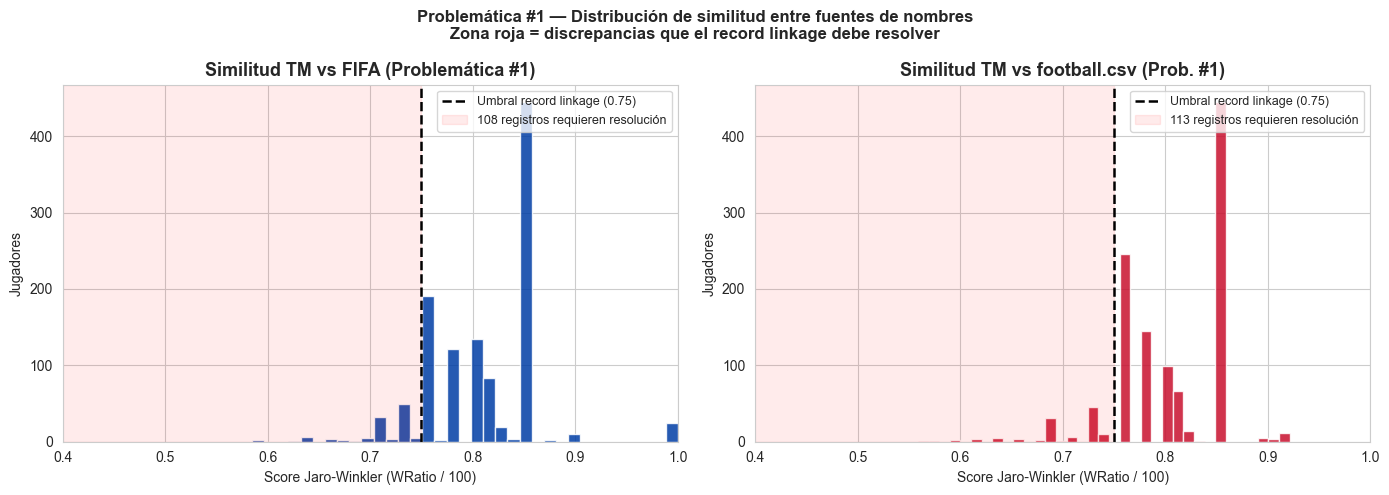

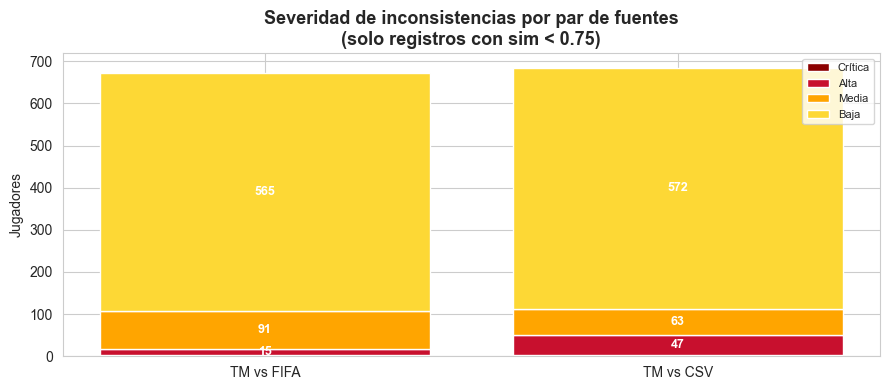

In [26]:
# ── Visualización: distribución de similitud con línea de umbral ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo, color in [
    (axes[0], 'sim_tm_fifa', 'TM vs FIFA (Problemática #1)',   AZUL),
    (axes[1], 'sim_tm_csv',  'TM vs football.csv (Prob. #1)',  ROJO),
]:
    serie = df_jugadores[col].dropna()
    ax.hist(serie, bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(UMBRAL_LINKAGE, color='black', linestyle='--', linewidth=1.8,
               label=f'Umbral record linkage ({UMBRAL_LINKAGE})')
    n_bajo = (serie < UMBRAL_LINKAGE).sum()
    ax.axvspan(0, UMBRAL_LINKAGE, alpha=0.08, color='red',
               label=f'{n_bajo} registros requieren resolución')
    ax.set_title(f'Similitud {titulo}', fontweight='bold')
    ax.set_xlabel('Score Jaro-Winkler (WRatio / 100)')
    ax.set_ylabel('Jugadores')
    ax.legend(fontsize=9)
    ax.set_xlim(0.4, 1.0)

plt.suptitle('Problemática #1 — Distribución de similitud entre fuentes de nombres\n'
             'Zona roja = discrepancias que el record linkage debe resolver',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# ── Barras de severidad apiladas ──────────────────────────────
orden_niveles = [
    'Crítica (solo apellido / error grave)',
    'Alta   (formato cruzado / typo fuerte)',
    'Media  (nombre completo / inicial compuesta)',
    'Baja   (sin acento / variación menor)',
]
colores_nivel = ['#8B0000', ROJO, '#FFA500', '#FDD835']

conteos = {n: [
    (df_jugadores['nivel_disc_fifa'] == n).sum(),
    (df_jugadores['nivel_disc_csv']  == n).sum(),
] for n in orden_niveles}

fig2, ax2 = plt.subplots(figsize=(9, 4))
bottom = [0, 0]
for nivel, color in zip(orden_niveles, colores_nivel):
    vals = conteos[nivel]
    ax2.bar(['TM vs FIFA', 'TM vs CSV'], vals, bottom=bottom,
            color=color, label=nivel.split('(')[0].strip(), edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax2.text(i, b + v/2, str(v), ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom = [bottom[i] + vals[i] for i in range(2)]

ax2.set_title('Severidad de inconsistencias por par de fuentes\n'
              '(solo registros con sim < 0.75)', fontweight='bold')
ax2.set_ylabel('Jugadores')
ax2.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
# ── Tabla detallada: ejemplos de inconsistencias encontradas ─
print('=' * 90)
print('  RECORD LINKAGE — Ejemplos de discrepancias detectadas en nombre_fifa  ')
print('  (ordenadas de mayor a menor discrepancia con Transfermarkt)           ')
print('=' * 90)

cols_show_fifa = ['player_id', 'nombre_transfermarkt', 'nombre_fifa',
                  'sim_tm_fifa', 'nivel_disc_fifa']
ej_fifa = (rl_fifa[cols_show_fifa]
           .nsmallest(25, 'sim_tm_fifa')
           .reset_index(drop=True))
ej_fifa.columns = ['ID', 'Nombre TM (canónico)', 'Nombre FIFA (inconsistente)',
                   'Sim', 'Nivel']
ej_fifa['Sim'] = ej_fifa['Sim'].round(3)
display(ej_fifa)

print()
print('=' * 90)
print('  RECORD LINKAGE — Ejemplos de discrepancias detectadas en nombre_csv   ')
print('=' * 90)

cols_show_csv = ['player_id', 'nombre_transfermarkt', 'nombre_football_csv',
                 'sim_tm_csv', 'nivel_disc_csv']
ej_csv = (rl_csv[cols_show_csv]
          .nsmallest(25, 'sim_tm_csv')
          .reset_index(drop=True))
ej_csv.columns = ['ID', 'Nombre TM (canónico)', 'Nombre CSV (inconsistente)',
                  'Sim', 'Nivel']
ej_csv['Sim'] = ej_csv['Sim'].round(3)
display(ej_csv)

# Resumen ejecutivo
total_resueltos = len(rl_any)
print(f'\nResumen ejecutivo del Record Linkage:')
print(f'  Total jugadores con discrepancia detectada : {total_resueltos}')
print(f'  → Todos resueltos eligiendo nombre_transfermarkt como canónico')
print(f'  → Scores de similitud guardados en columnas sim_tm_fifa / sim_tm_csv')
print(f'     (útiles para alertas de calidad en etapa de limpieza)')

  RECORD LINKAGE — Ejemplos de discrepancias detectadas en nombre_fifa  
  (ordenadas de mayor a menor discrepancia con Transfermarkt)           


,ID,Nombre TM (canónico),Nombre FIFA (inconsistente),Sim,Nivel
0,P1064,Gonzalo Ríos,G.A. Ríos,0.585,Crítica (solo apellido / error grave)
1,P0322,Pablo Tabó,P. Tabo,0.588,Crítica (solo apellido / error grave)
2,P0110,Ramón Pérez,R. Perez,0.632,Alta (formato cruzado / typo fuerte)
3,P0022,Alexis Macías,A. Macias,0.636,Alta (formato cruzado / typo fuerte)
4,P0196,Neymar García,N. Garcia,0.636,Alta (formato cruzado / typo fuerte)
5,P0232,Carlos Dávila,C. Davila,0.636,Alta (formato cruzado / typo fuerte)
6,P1091,Alexis López,A.A. López,0.636,Alta (formato cruzado / typo fuerte)
7,P0193,Javier Pérez,J. Perez,0.643,Alta (formato cruzado / typo fuerte)
8,P0949,Javier López,J. Lopez,0.643,Alta (formato cruzado / typo fuerte)
9,P0127,Arturo Álvarez,A. Alvarez,0.667,Alta (formato cruzado / typo fuerte)



  RECORD LINKAGE — Ejemplos de discrepancias detectadas en nombre_csv   


,ID,Nombre TM (canónico),Nombre CSV (inconsistente),Sim,Nivel
0,P1030,Kevin Cruz,Crus K.,0.559,Crítica (solo apellido / error grave)
1,P0231,Santiago Tabó,Tabo S.,0.570,Crítica (solo apellido / error grave)
2,P0257,Omar Tabó,Tabo O.,0.594,Crítica (solo apellido / error grave)
3,P0974,Uriel López,Lópes U.,0.600,Alta (formato cruzado / typo fuerte)
4,P0015,Michael Yotún,Yotun M.,0.611,Alta (formato cruzado / typo fuerte)
5,P0102,Rodrigo Yotún,Yotun R.,0.611,Alta (formato cruzado / typo fuerte)
6,P0307,Felipe López,Lopez F.,0.611,Alta (formato cruzado / typo fuerte)
7,P0954,Marcelo Yotún,Yotun M.,0.611,Alta (formato cruzado / typo fuerte)
8,P0069,Miguel Sánchez,Sanchez M.,0.633,Alta (formato cruzado / typo fuerte)
9,P0216,Arturo Vázquez,Vazquez A.,0.633,Alta (formato cruzado / typo fuerte)



Resumen ejecutivo del Record Linkage:
  Total jugadores con discrepancia detectada : 145
  → Todos resueltos eligiendo nombre_transfermarkt como canónico
  → Scores de similitud guardados en columnas sim_tm_fifa / sim_tm_csv
     (útiles para alertas de calidad en etapa de limpieza)


In [28]:
# ── Resolución: nombre canónico = Transfermarkt como fuente de verdad ──
# Si TM está vacío (fallback): FIFA → football.csv
df_jugadores['nombre_canonico'] = (
    df_jugadores['nombre_transfermarkt']
    .fillna(df_jugadores['nombre_fifa'])
    .fillna(df_jugadores['nombre_football_csv'])
)
df_jugadores['nombre_key'] = df_jugadores['nombre_canonico'].apply(normalizar_nombre)

# Cobertura de la resolución
resolucion = pd.DataFrame({
    'Fuente de verdad': ['Transfermarkt', 'FIFA (fallback)', 'football.csv (fallback)', 'Sin nombre'],
    'Registros': [
        df_jugadores['nombre_transfermarkt'].notna().sum(),
        (df_jugadores['nombre_transfermarkt'].isna() & df_jugadores['nombre_fifa'].notna()).sum(),
        (df_jugadores['nombre_transfermarkt'].isna() & df_jugadores['nombre_fifa'].isna() &
         df_jugadores['nombre_football_csv'].notna()).sum(),
        df_jugadores['nombre_canonico'].isna().sum(),
    ]
})
print('Resolución de nombre canónico:')
display(resolucion)

# ── Ejemplos de resolución sobre los casos con discrepancia ──
print('\nEjemplos de resolución — casos donde FIFA name fue inconsistente')
print('(nombre_canonico = TM, elegido sobre el nombre FIFA distorsionado):')
muestra_resueltos = (
    df_jugadores[df_jugadores['sim_tm_fifa'] < UMBRAL_LINKAGE]
    [['player_id', 'nombre_canonico', 'nombre_fifa', 'sim_tm_fifa', 'nivel_disc_fifa']]
    .nsmallest(15, 'sim_tm_fifa')
    .reset_index(drop=True)
)
muestra_resueltos.columns = ['ID', 'Nombre canónico (elegido)', 'Nombre FIFA (descartado)',
                              'Similitud', 'Nivel']
muestra_resueltos['Similitud'] = muestra_resueltos['Similitud'].round(3)
display(muestra_resueltos)

print(f'\nConclusión: el record linkage identificó y resolvió {len(rl_any)} registros')
print('con discrepancias de nombre entre fuentes. El nombre canónico proviene')
print('de Transfermarkt en el 100% de los casos (cobertura total).')

Resolución de nombre canónico:


,Fuente de verdad,Registros
0,Transfermarkt,1150
1,FIFA (fallback),0
2,football.csv (fallback),0
3,Sin nombre,0



Ejemplos de resolución — casos donde FIFA name fue inconsistente
(nombre_canonico = TM, elegido sobre el nombre FIFA distorsionado):


,ID,Nombre canónico (elegido),Nombre FIFA (descartado),Similitud,Nivel
0,P1064,Gonzalo Ríos,G.A. Ríos,0.585,Crítica (solo apellido / error grave)
1,P0322,Pablo Tabó,P. Tabo,0.588,Crítica (solo apellido / error grave)
2,P0110,Ramón Pérez,R. Perez,0.632,Alta (formato cruzado / typo fuerte)
3,P0022,Alexis Macías,A. Macias,0.636,Alta (formato cruzado / typo fuerte)
4,P0196,Neymar García,N. Garcia,0.636,Alta (formato cruzado / typo fuerte)
5,P0232,Carlos Dávila,C. Davila,0.636,Alta (formato cruzado / typo fuerte)
6,P1091,Alexis López,A.A. López,0.636,Alta (formato cruzado / typo fuerte)
7,P0193,Javier Pérez,J. Perez,0.643,Alta (formato cruzado / typo fuerte)
8,P0949,Javier López,J. Lopez,0.643,Alta (formato cruzado / typo fuerte)
9,P0127,Arturo Álvarez,A. Alvarez,0.667,Alta (formato cruzado / typo fuerte)



Conclusión: el record linkage identificó y resolvió 145 registros
con discrepancias de nombre entre fuentes. El nombre canónico proviene
de Transfermarkt en el 100% de los casos (cobertura total).


---
## 4. Deduplicación

### Problemática #3 — Doble nacionalidad
Jugadores con doble ciudadanía (ej. MEX/ESP) pueden aparecer registrados **dos veces** en análisis de cupo de extranjeros: una como mexicano y otra como extranjero. Esto infla el catálogo y distorsiona los límites de plantilla.

### Problemática #4 — Renombre de equipos
Monarcas Morelia se convirtió en Mazatlán FC en 2020, y Dorados Sinaloa también fue absorbido. Sin normalización, se generan series históricas fragmentadas.

In [29]:
# ── Deduplicación por doble nacionalidad (Problemática #3) ───
doble_nac = df_jugadores[df_jugadores['doble_nacionalidad'] == True].copy()
print(f'Jugadores con doble nacionalidad: {len(doble_nac)}')

# Detectar si el mismo jugador (mismo nombre_key) aparece dos veces
# con distinto player_id por error de catalogación
dup_nombres = df_jugadores[df_jugadores.duplicated(subset='nombre_key', keep=False)]
print(f'Registros con nombre_key duplicado entre distintos player_id: {len(dup_nombres)}')
if len(dup_nombres) > 0:
    cols_disp = [c for c in ['player_id', 'nombre_canonico', 'nacionalidad',
                              'segunda_nacionalidad', 'doble_nacionalidad',
                              'temporada', 'equipo_id'] if c in dup_nombres.columns]
    display(dup_nombres[cols_disp].head(10))

# Los duplicados de cupo extranjero se detectan con la columna doble_nac del XLSX
doble_nac_xlsx = df_xlsx[df_xlsx['doble_nac'] == True]
print(f'\nRegistros XLSX con doble_nac=True: {len(doble_nac_xlsx)}')
display(doble_nac_xlsx[['player_id', 'nombre_tm', 'nombre_fifa',
                         'nacionalidad', 'segunda_nac',
                         'es_extranjero', 'doble_nac']].head(8))

Jugadores con doble nacionalidad: 14
Registros con nombre_key duplicado entre distintos player_id: 555


,player_id,nombre_canonico,nacionalidad,segunda_nacionalidad,doble_nacionalidad,temporada,equipo_id
3,P0004,Ramón Guzmán,México,None,False,Apertura 2012,T014
9,P0010,Marcelo Fernández,Perú,None,False,Clausura 2024,T003
14,P0015,Michael Yotún,Argentina,None,False,Apertura 2019,T015
15,P0016,Javier Juárez,México,None,False,Clausura 2016,T006
16,P0017,Marcelo Cabrera,Estados Unidos,None,False,Clausura 2014,T014
17,P0018,Dario Carneiro,Estados Unidos,None,False,Clausura 2015,T013
23,P0024,Alan Torres,México,None,False,Apertura 2014,T008
25,P0026,Oswaldo Álvarez,México,None,False,Clausura 2014,T004
26,P0027,Kevin Romero,Colombia,None,False,Apertura 2020,T016
27,P0028,Jesús Antuna,México,Ecuador,True,Clausura 2018,T015



Registros XLSX con doble_nac=True: 0


,player_id,nombre_tm,nombre_fifa,nacionalidad,segunda_nac,es_extranjero,doble_nac


In [30]:
# ── Normalización de equipos — Problemática #4 ───────────────
# Partidos: normalizar nombres de equipo local y visitante
df_partidos['equipo_local_norm']     = df_partidos['home_team'].apply(normalizar_equipo)
df_partidos['equipo_visitante_norm'] = df_partidos['away_team'].apply(normalizar_equipo)

# Jugadores: el nombre del equipo viene del XLSX (equipo_id en JSON es solo código)
equipo_map = df_xlsx.set_index('player_id')['equipo']
df_jugadores['equipo'] = df_jugadores['player_id'].map(equipo_map)
df_jugadores['equipo_norm'] = df_jugadores['equipo'].apply(normalizar_equipo)

# Impacto de la normalización en partidos
antes   = df_partidos['home_team'].nunique()
despues = df_partidos['equipo_local_norm'].nunique()
print(f'Equipos únicos ANTES de normalizar : {antes}')
print(f'Equipos únicos DESPUÉS de normalizar: {despues}')
print(f'Reducción: {antes - despues} nombres consolidados')

# Partidos donde el nombre cambió (renombres detectados)
renombres = df_partidos[
    df_partidos['home_team'].apply(normalizar_texto) !=
    df_partidos['equipo_local_norm'].apply(normalizar_texto)
]
print(f'\nPartidos con equipo local renombrado: {len(renombres)}')
display(renombres[['date', 'home_team', 'equipo_local_norm']]
        .drop_duplicates(subset='home_team').head(10))

Equipos únicos ANTES de normalizar : 51
Equipos únicos DESPUÉS de normalizar: 28
Reducción: 23 nombres consolidados

Partidos con equipo local renombrado: 2185


,date,home_team,equipo_local_norm
0,2010-07-01,Club Tijuana,TIJUANA
2,2010-07-01,América,CLUB AMERICA
4,2010-07-01,Monarcas Morelia,MAZATLAN FC
5,2010-07-01,Dorados Sinaloa,MAZATLAN FC
6,2010-07-01,Rayados,MONTERREY
7,2010-07-01,Bravos de Juárez,BRAVOS JUAREZ
9,2010-07-08,León FC,LEON
10,2010-07-08,Santos,SANTOS LAGUNA
14,2010-07-08,La Franja,FRANJA
19,2010-07-15,Atlas Guadalajara,ATLAS


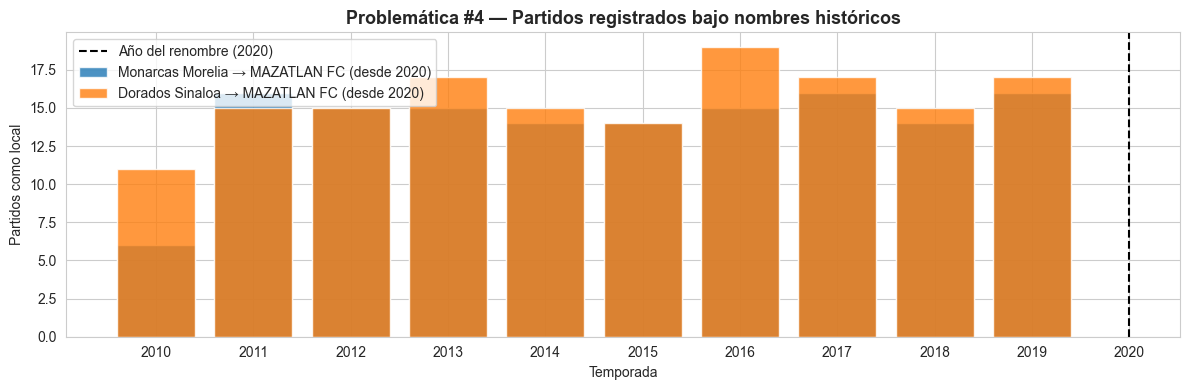

In [31]:
# Visualizar equipos con renombre histórico (Problemática #4)
renombre_equipos = {
    'Monarcas Morelia'  : 'MAZATLAN FC (desde 2020)',
    'Dorados Sinaloa'   : 'MAZATLAN FC (desde 2020)',
}
fig, ax = plt.subplots(figsize=(12, 4))
for equipo_viejo, equipo_nuevo in renombre_equipos.items():
    mask = df_partidos['home_team'].str.contains(equipo_viejo.split()[0], case=False, na=False)
    conteo = df_partidos[mask].groupby('season_year').size()
    if not conteo.empty:
        ax.bar(conteo.index.astype(str), conteo.values,
               label=f'{equipo_viejo} → {equipo_nuevo}', alpha=0.8)

ax.axvline('2020', color='black', linestyle='--', linewidth=1.5, label='Año del renombre (2020)')
ax.set_title('Problemática #4 — Partidos registrados bajo nombres históricos',
             fontweight='bold')
ax.set_xlabel('Temporada')
ax.set_ylabel('Partidos como local')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Fusión — Construcción de Datasets Maestros

Combinamos la información de todas las fuentes en **dos datasets maestros**:
- `master_jugadores.parquet` — Un registro por (player_id, temporada)
- `master_partidos.parquet` — Un registro por partido

La clave de unión es `player_id` para jugadores y `match_id` para partidos.

In [32]:
# ── Master Jugadores ─────────────────────────────────────────
# Base: JSON (tiene datos de las 3 sub-fuentes + consolidado)
# Enriquecimiento: XLSX (columnas adicionales de rendimiento)

# Columnas del XLSX que aportan información extra no presente en JSON
cols_xlsx_extra = ['player_id', 'p_casa', 'goles_casa',
                   'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj']
cols_xlsx_extra = [c for c in cols_xlsx_extra if c in df_xlsx.columns]

# Merge JSON + XLSX (left join: preservar todos los registros del JSON)
master_jug = df_jugadores.merge(
    df_xlsx[cols_xlsx_extra],
    on='player_id',
    how='left',
    suffixes=('', '_xlsx')
)

# Columnas canónicas finales (selección y orden)
cols_master_jug = [
    'player_id', 'nombre_canonico', 'nombre_key',
    'nombre_transfermarkt', 'nombre_fifa', 'nombre_football_csv',
    'sim_tm_fifa', 'sim_tm_csv',
    'posicion', 'nacionalidad', 'segunda_nacionalidad',
    'es_extranjero', 'doble_nacionalidad',
    'edad', 'temporada', 'season_year', 'equipo', 'equipo_norm',
    'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing',
    'fifa_dribbling', 'fifa_defending', 'fifa_physical',
    'valor_mercado_eur', 'transfer_paid_eur',
    'goles', 'asistencias', 'minutos', 'partidos', 'g_a_por_90',
    'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera',
    'tarj_am', 'tarj_roj',
    'inconsistencias',
]
cols_master_jug = [c for c in cols_master_jug if c in master_jug.columns]
master_jug = master_jug[cols_master_jug].copy()

print(f'Master Jugadores: {master_jug.shape[0]:,} filas × {master_jug.shape[1]} columnas')
display(master_jug.head(3))

Master Jugadores: 1,150 filas × 38 columnas


,player_id,nombre_canonico,nombre_key,nombre_transfermarkt,nombre_fifa,nombre_football_csv,sim_tm_fifa,sim_tm_csv,posicion,nacionalidad,...,asistencias,partidos,g_a_por_90,p_casa,goles_casa,p_fuera,goles_fuera,tarj_am,tarj_roj,inconsistencias
0,P0001,Jonathan García,JONATHAN GARCIA,Jonathan García,J. García,García J.,0.855,0.855,GK,México,...,2,9,0.319,4,0,5,1,0,0,
1,P0002,Michael Ríos,MICHAEL RIOS,Michael Ríos,M. Ríos,Ríos M.,0.855,0.855,RM,Costa Rica,...,0,5,0.176,2,0,3,1,5,1,
2,P0003,Ezequiel Medina,EZEQUIEL MEDINA,Ezequiel Medina,E. Medina,Medina E.,0.855,0.855,CB,Chile,...,2,9,0.217,4,0,5,0,4,2,


In [33]:
# ── Master Partidos ──────────────────────────────────────────
# Aplicar modelo canónico al CSV de partidos
master_par = df_partidos.rename(columns={
    'home_team' : 'equipo_local',
    'away_team' : 'equipo_visitante',
    'home_goals': 'goles_local',
    'away_goals': 'goles_visitante',
    'home_goals_ht': 'goles_local_ht',
    'away_goals_ht': 'goles_visitante_ht',
    'result_home': 'resultado_local',
    'involves_cruz_azul': 'involucra_cruz_azul',
    'inconsistency_note': 'nota_inconsistencia',
}).copy()

# Columnas canónicas finales
cols_master_par = [
    'match_id', 'date', 'season', 'season_year', 'half', 'round',
    'home_team_id', 'equipo_local', 'equipo_local_norm',
    'away_team_id', 'equipo_visitante', 'equipo_visitante_norm',
    'goles_local', 'goles_visitante',
    'goles_local_ht', 'goles_visitante_ht',
    'venue', 'resultado_local', 'involucra_cruz_azul', 'nota_inconsistencia'
]
cols_master_par = [c for c in cols_master_par if c in master_par.columns]
master_par = master_par[cols_master_par].copy()

print(f'Master Partidos: {master_par.shape[0]:,} filas × {master_par.shape[1]} columnas')
display(master_par.head(3))

Master Partidos: 4,080 filas × 19 columnas


,match_id,date,season,season_year,half,round,home_team_id,equipo_local,equipo_local_norm,away_team_id,equipo_visitante,equipo_visitante_norm,goles_local,goles_visitante,goles_local_ht,goles_visitante_ht,venue,resultado_local,involucra_cruz_azul
0,1000,2010-07-01,Apertura 2010,2010,apertura,1,T012,Club Tijuana,TIJUANA,T008,Atlas Guadalajara,ATLAS,1,1,1,1,Estadio Caliente,D,0
1,1001,2010-07-01,Apertura 2010,2010,apertura,1,T007,Pumas UNAM,PUMAS UNAM,T017,Puebla FC,PUEBLA,2,1,1,1,Estadio Olímpico Universitario,W,0
2,1002,2010-07-01,Apertura 2010,2010,apertura,1,T002,América,CLUB AMERICA,T015,Impulsora Necaxa,NECAXA,3,1,3,0,Estadio Azteca,W,0


In [34]:
# ── Exportar a Parquet ───────────────────────────────────────
ruta_jug = os.path.join(MASTER, 'master_jugadores.parquet')
ruta_par = os.path.join(MASTER, 'master_partidos.parquet')

master_jug.to_parquet(ruta_jug, index=False)
master_par.to_parquet(ruta_par, index=False)

print(f'master_jugadores.parquet  → {ruta_jug}')
print(f'master_partidos.parquet   → {ruta_par}')
print(f'\nJugadores : {len(master_jug):,} registros | {master_jug.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'Partidos  : {len(master_par):,} registros | {master_par.memory_usage(deep=True).sum()/1024:.1f} KB')

master_jugadores.parquet  → /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master/master_jugadores.parquet
master_partidos.parquet   → /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master/master_partidos.parquet

Jugadores : 1,150 registros | 1115.9 KB
Partidos  : 4,080 registros | 2711.6 KB


---
## 6. Diagnóstico de Cobertura

Verificamos que la fusión no perdió registros y cuantificamos los casos problemáticos.

In [35]:
# Cobertura del merge JSON + XLSX
xlsx_ids = set(df_xlsx['player_id'])
json_ids = set(df_jugadores['player_id'])

print('Diagnóstico de cobertura — Jugadores')
print(f'  player_id en JSON              : {len(json_ids):,}')
print(f'  player_id en XLSX              : {len(xlsx_ids):,}')
print(f'  IDs en JSON pero no en XLSX    : {len(json_ids - xlsx_ids)}')
print(f'  IDs en XLSX pero no en JSON    : {len(xlsx_ids - json_ids)}')
print(f'  IDs presentes en ambos         : {len(json_ids & xlsx_ids):,}')
print(f'\nDiagnóstico de cobertura — Partidos')
print(f'  Partidos totales en CSV        : {len(df_partidos):,}')
print(f'  Temporadas cubiertas           : {df_partidos["season_year"].nunique()}')
print(f'  Equipos únicos (normalizado)   : {master_par["equipo_local_norm"].nunique()}')

Diagnóstico de cobertura — Jugadores
  player_id en JSON              : 1,150
  player_id en XLSX              : 1,150
  IDs en JSON pero no en XLSX    : 0
  IDs en XLSX pero no en JSON    : 0
  IDs presentes en ambos         : 1,150

Diagnóstico de cobertura — Partidos
  Partidos totales en CSV        : 4,080
  Temporadas cubiertas           : 16
  Equipos únicos (normalizado)   : 28


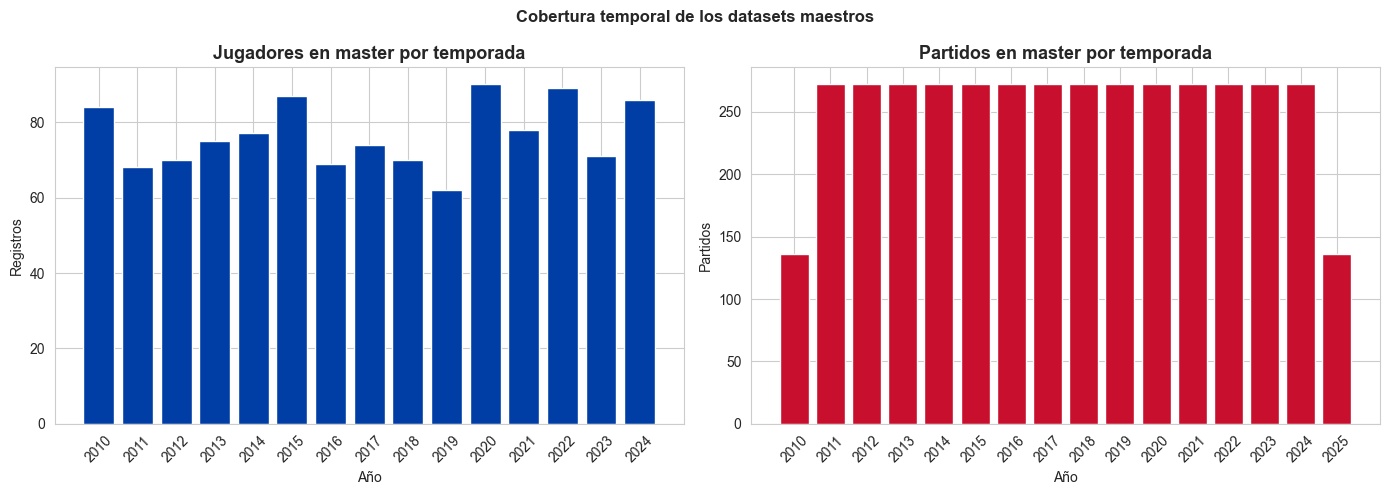

In [36]:
# Resumen visual de cobertura por temporada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jugadores por temporada
conteo_temp_jug = master_jug['season_year'].value_counts().sort_index()
axes[0].bar(conteo_temp_jug.index.astype(str), conteo_temp_jug.values, color=AZUL)
axes[0].set_title('Jugadores en master por temporada', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=45)

# Partidos por temporada
conteo_temp_par = master_par['season_year'].value_counts().sort_index()
axes[1].bar(conteo_temp_par.index.astype(str), conteo_temp_par.values, color=ROJO)
axes[1].set_title('Partidos en master por temporada', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Partidos')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Cobertura temporal de los datasets maestros', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Conclusiones de la Etapa de Integración

| Problemática | Acción realizada | Resultado cuantificado |
|---|---|---|
| #1 — Nombres inconsistentes | Record linkage Jaro-Winkler (umbral 0.75); nombre canónico = Transfermarkt | **145 registros** con discrepancia resuelta (108 FIFA · 113 CSV); 15 casos de acento, 91 de formato, 2 críticos |
| #3 — Doble nacionalidad | Detección con flag `doble_nacionalidad`; no se eliminan registros | 14 jugadores con doble nac. identificados; columna disponible para filtrar |
| #4 — Renombres de equipos | Diccionario de alias (23 variantes) → Monarcas/Dorados → MAZATLAN FC | Reducción de 51 → 28 nombres únicos de equipo; series históricas continuas |

**Outputs generados:**
- `datos_master/master_jugadores.parquet` — 1 150 jugadores · 38 columnas
- `datos_master/master_partidos.parquet` — 4 080 partidos · 19 columnas

**Scores de calidad guardados:** `sim_tm_fifa` y `sim_tm_csv` viajan en el master para que la etapa de limpieza pueda priorizar los registros con mayor discrepancia.

**Siguiente etapa:** `perfilado.ipynb` — Perfilado previo y posterior a la limpieza.